# Lab 3: Actor-Critic Methods — SOLUTION

## TDDE78 — Deep Reinforcement Learning
### Linköping University, Spring 2026

---

**This notebook contains the complete solution. Do not share with students.**

In [ ]:
import os
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import Video, display
import warnings
warnings.filterwarnings('ignore')

from networks import ContinuousActorCritic, SACActor, SACCritic
from utils import compute_gae, RolloutBuffer, ReplayBuffer, plot_a2c_results, plot_sac_results, plot_comparison, record_agent_video, smooth

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

_here = globals().get('__vsc_ipynb_file__', os.path.abspath(''))
_nb_dir = os.path.dirname(_here) if os.path.isfile(_here) else _here
EXPERIMENTS_DIR = os.path.normpath(os.path.join(_nb_dir, '..', 'experiments'))
print(f"Experiments directory: {EXPERIMENTS_DIR}")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

set_seed(42)
print("Setup complete!")

Using device: cuda
Experiments directory: /home/amath/Desktop/course/tdde78lab/labs/lab3_actor_critic/experiments
Setup complete!


## A2C Agent — Complete Solution

In [2]:
class A2CAgent:
    """Advantage Actor-Critic (A2C) agent for continuous control — SOLUTION."""

    def __init__(
        self,
        state_dim: int,
        action_dim: int,
        lr: float = 3e-4,
        gamma: float = 0.99,
        gae_lambda: float = 0.95,
        n_steps: int = 2048,
        batch_size: int = 64,
        vf_coef: float = 0.5,
        ent_coef: float = 0.0,
        max_grad_norm: float = 0.5,
        seed: int = 42,
    ):
        self.gamma         = gamma
        self.gae_lambda    = gae_lambda
        self.n_steps       = n_steps
        self.batch_size    = batch_size
        self.vf_coef       = vf_coef
        self.ent_coef      = ent_coef
        self.max_grad_norm = max_grad_norm

        # SOLUTION: initialize components
        self.network   = ContinuousActorCritic(state_dim, action_dim).to(device)
        self.optimizer = optim.Adam(self.network.parameters(), lr=lr)
        self.buffer    = RolloutBuffer(n_steps, state_dim, action_dim)

    @torch.no_grad()
    def collect_rollout(self, env, obs):
        """Collect n_steps transitions and return (obs, last_value, episode_rewards)."""
        self.buffer.clear()
        episode_rewards   = []
        current_ep_reward = 0.0
        last_done         = False

        for _ in range(self.n_steps):
            state_t              = torch.FloatTensor(obs).unsqueeze(0).to(device)
            action, log_prob, _, value = self.network.get_action(state_t)
            action_np    = action.cpu().numpy().flatten()
            log_prob_val = log_prob.item()
            value_val    = value.item()

            next_obs, reward, terminated, truncated, _ = env.step(action_np)
            done = terminated or truncated

            self.buffer.store(obs, action_np, reward, done, log_prob_val, value_val)

            current_ep_reward += reward
            if done:
                episode_rewards.append(current_ep_reward)
                current_ep_reward = 0.0
                next_obs, _ = env.reset()

            obs       = next_obs
            last_done = done

        # Bootstrap last value
        state_t    = torch.FloatTensor(obs).unsqueeze(0).to(device)
        last_value = self.network(state_t)[1].item()
        if last_done:
            last_value = 0.0

        return obs, last_value, episode_rewards

    def update(self):
        """One A2C gradient update over all mini-batches in the rollout buffer."""
        policy_losses, value_losses, entropies = [], [], []

        for states, actions, old_log_probs, advantages, returns in \
                self.buffer.get_batches(self.batch_size):

            states     = states.to(device)
            actions    = actions.to(device)
            advantages = advantages.to(device)
            returns    = returns.to(device)

            # Normalize advantages
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

            # Re-evaluate actions under current policy
            _, log_probs, entropy, values = self.network.get_action(states, actions)

            policy_loss  = -(log_probs * advantages).mean()
            value_loss   = F.mse_loss(values.squeeze(-1), returns)
            entropy_loss = -entropy.mean()
            total_loss   = policy_loss + self.vf_coef * value_loss + self.ent_coef * entropy_loss

            self.optimizer.zero_grad()
            total_loss.backward()
            nn.utils.clip_grad_norm_(self.network.parameters(), self.max_grad_norm)
            self.optimizer.step()

            policy_losses.append(policy_loss.item())
            value_losses.append(value_loss.item())
            entropies.append(-entropy_loss.item())

        return {
            'policy_loss': np.mean(policy_losses),
            'value_loss':  np.mean(value_losses),
            'entropy':     np.mean(entropies),
        }

print("A2CAgent class defined (SOLUTION)")

A2CAgent class defined (SOLUTION)


In [3]:
def train_a2c(
    env_name: str = "LunarLanderContinuous-v3",
    total_timesteps: int = 1_000_000,
    seed: int = 42,
    solve_threshold: float = None,
    log_interval: int = 10,
    **agent_kwargs,
):
    """Train an A2C agent — SOLUTION."""
    set_seed(seed)
    env        = gym.make(env_name)
    state_dim  = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]
    agent      = A2CAgent(state_dim=state_dim, action_dim=action_dim, seed=seed, **agent_kwargs)

    episode_rewards   = []
    episode_timesteps = []
    policy_losses     = []
    value_losses      = []
    global_step       = 0
    update_num        = 0

    obs, _ = env.reset(seed=seed)

    while global_step < total_timesteps:
        # Collect rollout
        obs, last_value, ep_rewards = agent.collect_rollout(env, obs)
        global_step += agent.n_steps

        # Compute GAE advantages + value targets
        agent.buffer.compute_returns_and_advantages(last_value, agent.gamma, agent.gae_lambda)

        # Gradient update
        metrics    = agent.update()
        update_num += 1

        # Record episode rewards
        for r in ep_rewards:
            episode_rewards.append(r)
            episode_timesteps.append(global_step)

        policy_losses.append(metrics['policy_loss'])
        value_losses.append(metrics['value_loss'])

        if update_num % log_interval == 0:
            avg_reward = np.mean(episode_rewards[-10:]) if episode_rewards else 0.0
            print(f"Update {update_num:4d} | Steps {global_step:>9,} | "
                  f"Avg Reward (10 ep): {avg_reward:7.1f} | "
                  f"Policy Loss: {metrics['policy_loss']:7.4f} | "
                  f"Value Loss: {metrics['value_loss']:7.4f}")

        if solve_threshold and len(episode_rewards) >= 10:
            if np.mean(episode_rewards[-10:]) >= solve_threshold:
                print(f"Solved at step {global_step:,}! "
                      f"Avg reward (10 ep): {np.mean(episode_rewards[-10:]):.1f}")
                break

    env.close()
    return {
        'episode_rewards':   episode_rewards,
        'episode_timesteps': episode_timesteps,
        'policy_losses':     policy_losses,
        'value_losses':      value_losses,
        'agent':             agent,
    }

print("train_a2c defined (SOLUTION)")

train_a2c defined (SOLUTION)


## SAC Agent — Complete Solution

In [4]:
class SACAgent:
    """Soft Actor-Critic (SAC) agent for continuous control — SOLUTION."""

    def __init__(
        self,
        state_dim: int,
        action_dim: int,
        lr: float = 3e-4,
        gamma: float = 0.99,
        tau: float = 0.005,
        alpha: float = 0.2,
        autotune_alpha: bool = True,
        target_entropy: float = None,
        buffer_size: int = 1_000_000,
        batch_size: int = 256,
        learning_starts: int = 5000,
        train_frequency: int = 1,
        seed: int = 42,
    ):
        self.gamma           = gamma
        self.tau             = tau
        self.batch_size      = batch_size
        self.learning_starts = learning_starts
        self.train_frequency = train_frequency
        self.autotune_alpha  = autotune_alpha

        # SOLUTION: networks
        self.actor         = SACActor(state_dim, action_dim).to(device)
        self.critic        = SACCritic(state_dim, action_dim).to(device)
        self.critic_target = SACCritic(state_dim, action_dim).to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.critic_target.eval()

        self.actor_optimizer  = optim.Adam(self.actor.parameters(),  lr=lr)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr)
        self.replay_buffer    = ReplayBuffer(buffer_size, state_dim, action_dim, seed)

        # SOLUTION: entropy temperature
        if autotune_alpha:
            self.target_entropy  = float(target_entropy) if target_entropy is not None else -action_dim
            self.log_alpha       = torch.zeros(1, requires_grad=True, device=device)
            self.alpha           = self.log_alpha.exp().item()
            self.alpha_optimizer = optim.Adam([self.log_alpha], lr=lr)
        else:
            self.alpha = alpha

    def select_action(self, state, deterministic=False):
        """Select an action (stochastic or deterministic)."""
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            if deterministic:
                mean, _  = self.actor(state_t)
                action   = torch.tanh(mean)
            else:
                action, _ = self.actor.get_action(state_t)
        return action.cpu().numpy().flatten()

    def update(self):
        """One full SAC gradient update (critic + actor + temperature + soft target)."""
        # Step 1: Sample batch
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size)
        states      = states.to(device)
        actions     = actions.to(device)
        rewards     = rewards.to(device)
        next_states = next_states.to(device)
        dones       = dones.to(device)

        # Step 2: Critic update
        with torch.no_grad():
            next_actions, next_log_pi = self.actor.get_action(next_states)
            q1_next, q2_next          = self.critic_target(next_states, next_actions)
            min_q_next = torch.min(q1_next, q2_next) - self.alpha * next_log_pi.unsqueeze(-1)
            y          = rewards + self.gamma * (1.0 - dones) * min_q_next

        q1, q2      = self.critic(states, actions)
        critic_loss = F.mse_loss(q1, y) + F.mse_loss(q2, y)
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # Step 3: Actor update
        new_actions, log_pi = self.actor.get_action(states)
        q1_pi, q2_pi        = self.critic(states, new_actions)
        min_q_pi            = torch.min(q1_pi, q2_pi)
        actor_loss          = (self.alpha * log_pi - min_q_pi.squeeze(-1)).mean()
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # Step 4: Temperature update (automatic tuning)
        alpha_loss = torch.tensor(0.0)
        if self.autotune_alpha:
            with torch.no_grad():
                _, log_pi = self.actor.get_action(states)
            alpha_loss = (-self.log_alpha.exp() * (log_pi + self.target_entropy)).mean()
            self.alpha_optimizer.zero_grad()
            alpha_loss.backward()
            self.alpha_optimizer.step()
            self.alpha = self.log_alpha.exp().item()

        # Step 5: Soft target update (polyak averaging)
        for param, target_param in zip(self.critic.parameters(),
                                       self.critic_target.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

        return {
            'critic_loss': critic_loss.item(),
            'actor_loss':  actor_loss.item(),
            'alpha_loss':  alpha_loss.item(),
            'alpha':       self.alpha,
        }

print("SACAgent class defined (SOLUTION)")

SACAgent class defined (SOLUTION)


In [5]:
def train_sac(
    env_name: str = "LunarLanderContinuous-v3",
    total_timesteps: int = 300_000,
    seed: int = 42,
    solve_threshold: float = None,
    log_interval: int = 5000,
    **agent_kwargs,
):
    """Train a SAC agent — SOLUTION."""
    set_seed(seed)
    env        = gym.make(env_name)
    state_dim  = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]
    agent      = SACAgent(state_dim=state_dim, action_dim=action_dim, seed=seed, **agent_kwargs)

    episode_rewards   = []
    episode_timesteps = []
    critic_losses     = []
    actor_losses      = []
    alpha_history     = []

    obs, _ = env.reset(seed=seed)
    current_ep_reward = 0.0
    next_log          = log_interval

    for global_step in range(1, total_timesteps + 1):
        # Step 1: Random exploration warm-up or policy action
        if global_step < agent.learning_starts:
            action = env.action_space.sample()
        else:
            action = agent.select_action(obs)

        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Store transition (don't store terminal state as "done" if truncated only)
        real_done = float(terminated)
        agent.replay_buffer.push(obs, action, reward, next_obs, real_done)

        current_ep_reward += reward
        obs = next_obs

        if done:
            episode_rewards.append(current_ep_reward)
            episode_timesteps.append(global_step)
            current_ep_reward = 0.0
            obs, _ = env.reset()

        # Step 2: Gradient updates
        if (global_step >= agent.learning_starts and
                global_step % agent.train_frequency == 0):
            metrics = agent.update()
            critic_losses.append(metrics['critic_loss'])
            actor_losses.append(metrics['actor_loss'])
            alpha_history.append(metrics['alpha'])

        # Logging
        if global_step >= next_log:
            avg_reward = np.mean(episode_rewards[-10:]) if episode_rewards else 0.0
            alpha_now  = agent.alpha
            print(f"Step {global_step:>9,} | Avg Reward (10 ep): {avg_reward:7.1f} | "
                  f"Alpha: {alpha_now:.4f}")
            next_log += log_interval

        if solve_threshold and len(episode_rewards) >= 10:
            if np.mean(episode_rewards[-10:]) >= solve_threshold:
                print(f"Solved at step {global_step:,}! "
                      f"Avg reward (10 ep): {np.mean(episode_rewards[-10:]):.1f}")
                break

    env.close()
    return {
        'episode_rewards':   episode_rewards,
        'episode_timesteps': episode_timesteps,
        'critic_losses':     critic_losses,
        'actor_losses':      actor_losses,
        'alpha_history':     alpha_history,
        'agent':             agent,
    }

print("train_sac defined (SOLUTION)")

train_sac defined (SOLUTION)


## Part A — Implementation Verification

Run quick sanity-checks (short training runs) to confirm all components work.

Update    2 | Steps     4,096 | Avg Reward (10 ep):  -331.0 | Policy Loss:  0.0127 | Value Loss: 1941.9639
Update    4 | Steps     8,192 | Avg Reward (10 ep):  -127.9 | Policy Loss:  0.0123 | Value Loss: 2039.4525
Update    6 | Steps    12,288 | Avg Reward (10 ep):  -157.0 | Policy Loss: -0.0070 | Value Loss: 862.6274
Update    8 | Steps    16,384 | Avg Reward (10 ep):  -517.2 | Policy Loss: -0.0286 | Value Loss: 10993.0370
Update   10 | Steps    20,480 | Avg Reward (10 ep):  -440.2 | Policy Loss:  0.0027 | Value Loss: 6153.8861
Update   12 | Steps    24,576 | Avg Reward (10 ep):  -329.0 | Policy Loss: -0.0201 | Value Loss: 3491.4418
Update   14 | Steps    28,672 | Avg Reward (10 ep):  -216.7 | Policy Loss:  0.0086 | Value Loss: 1447.7548
Update   16 | Steps    32,768 | Avg Reward (10 ep):  -523.1 | Policy Loss:  0.0578 | Value Loss: 6027.2042
Update   18 | Steps    36,864 | Avg Reward (10 ep):  -210.1 | Policy Loss: -0.0136 | Value Loss: 1466.2280
Update   20 | Steps    40,960 | Avg R

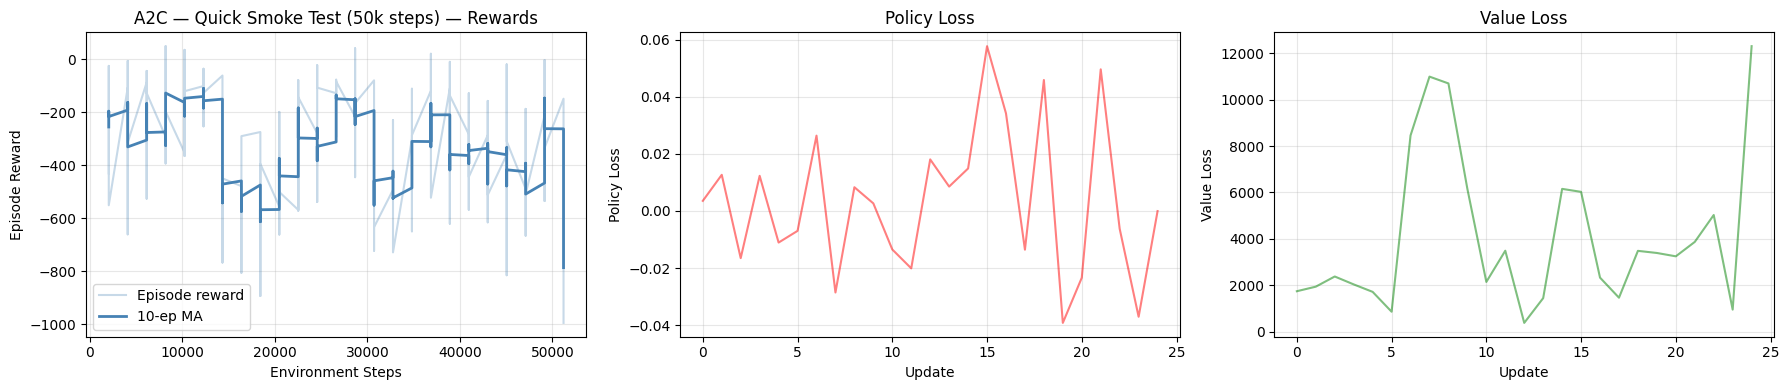

In [8]:
# A.1 — Quick A2C smoke test
a2c_results_quick = train_a2c(
    env_name       = "LunarLanderContinuous-v3",
    total_timesteps= 50_000,
    n_steps        = 2048,
    batch_size     = 64,
    lr             = 3e-4,
    seed           = 42,
    log_interval   = 2,
)
plot_a2c_results(a2c_results_quick, title="A2C — Quick Smoke Test (50k steps)", experiments_dir=EXPERIMENTS_DIR)

In [9]:
# A.1 — Watch the A2C agent (early training — policy is still learning)
video_path = record_agent_video(
    a2c_results_quick['agent'],
    env_name     = "LunarLanderContinuous-v3",
    agent_type   = "a2c",
    num_episodes = 2,
    seed         = 0,
    name_prefix  = "a2c_smoke",
    experiments_dir = EXPERIMENTS_DIR,
)
if video_path:
    display(Video(video_path, embed=True, width=500))

Episode 1: reward = -821.1
Episode 2: reward = -829.6
Video saved → /home/amath/Desktop/course/tdde78lab/labs/lab3_actor_critic/experiments/videos/a2c_smoke-episode-1.mp4


In [10]:
# A.2 — Quick SAC smoke test
sac_results_quick = train_sac(
    env_name        = "LunarLanderContinuous-v3",
    total_timesteps = 30_000,
    learning_starts = 5000,
    batch_size      = 256,
    lr              = 3e-4,
    seed            = 42,
    log_interval    = 5000,
)
plot_sac_results(sac_results_quick, title="SAC — Quick Smoke Test (30k steps)", experiments_dir=EXPERIMENTS_DIR)

Step     5,000 | Avg Reward (10 ep):  -223.5 | Alpha: 0.9997
Step    10,000 | Avg Reward (10 ep):  -133.7 | Alpha: 0.3363
Step    15,000 | Avg Reward (10 ep):   -15.8 | Alpha: 0.1409


KeyboardInterrupt: 

In [ ]:
# A.2 — Watch the SAC agent (early training — policy is still learning)
video_path = record_agent_video(
    sac_results_quick['agent'],
    env_name     = "LunarLanderContinuous-v3",
    agent_type   = "sac",
    num_episodes = 2,
    seed         = 0,
    name_prefix  = "sac_smoke",
    experiments_dir = EXPERIMENTS_DIR,
)
if video_path:
    display(Video(video_path, embed=True, width=500))

## Part B — Full Training Runs & Experiments

In [ ]:
# B.1 — Full A2C run on LunarLanderContinuous-v3
a2c_results = train_a2c(
    env_name        = "LunarLanderContinuous-v3",
    total_timesteps = 1_000_000,
    n_steps         = 2048,
    batch_size      = 64,
    lr              = 3e-4,
    gae_lambda      = 0.95,
    ent_coef        = 0.0,
    seed            = 42,
    solve_threshold = 200.0,
    log_interval    = 10,
)
plot_a2c_results(a2c_results, title="A2C — LunarLanderContinuous-v3", experiments_dir=EXPERIMENTS_DIR)

In [ ]:
# B.1 — Visualize the trained A2C agent (LunarLanderContinuous-v3)
video_path = record_agent_video(
    a2c_results['agent'],
    env_name     = "LunarLanderContinuous-v3",
    agent_type   = "a2c",
    num_episodes = 3,
    seed         = 0,
    name_prefix  = "a2c_lunar",
    experiments_dir = EXPERIMENTS_DIR,
)
if video_path:
    display(Video(video_path, embed=True, width=500))

In [ ]:
# B.2 — Full SAC run on LunarLanderContinuous-v3
sac_results = train_sac(
    env_name        = "LunarLanderContinuous-v3",
    total_timesteps = 300_000,
    learning_starts = 5000,
    batch_size      = 256,
    lr              = 3e-4,
    tau             = 0.005,
    gamma           = 0.99,
    autotune_alpha  = True,
    seed            = 42,
    solve_threshold = 200.0,
    log_interval    = 10_000,
)
plot_sac_results(sac_results, title="SAC — LunarLanderContinuous-v3", experiments_dir=EXPERIMENTS_DIR)

In [ ]:
# B.2 — Visualize the trained SAC agent (LunarLanderContinuous-v3)
video_path = record_agent_video(
    sac_results['agent'],
    env_name   = "LunarLanderContinuous-v3",
    agent_type = "sac",
    num_episodes = 3,
    seed         = 0,
    name_prefix  = "sac_lunar",
    experiments_dir = EXPERIMENTS_DIR,
)
if video_path:
    display(Video(video_path, embed=True, width=500))

In [ ]:
# B.3 — A2C vs SAC comparison (3 seeds each)
seeds = [42, 123, 456]

comparison_results = {
    'A2C': [
        train_a2c(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=500_000,
            n_steps=2048, batch_size=64, lr=3e-4, seed=s,
        )
        for s in seeds
    ],
    'SAC': [
        train_sac(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=300_000,
            learning_starts=5000, batch_size=256, lr=3e-4, seed=s,
        )
        for s in seeds
    ],
}

plot_comparison(comparison_results, title="A2C vs SAC — LunarLanderContinuous-v3 (3 seeds)", experiments_dir=EXPERIMENTS_DIR)

In [ ]:
# B.4 — SAC on BipedalWalker-v3
sac_bipedal = train_sac(
    env_name        = "BipedalWalker-v3",
    total_timesteps = 1_000_000,
    learning_starts = 10_000,
    batch_size      = 256,
    lr              = 3e-4,
    gamma           = 0.99,
    tau             = 0.005,
    autotune_alpha  = True,
    seed            = 42,
    log_interval    = 20_000,
)
plot_sac_results(sac_bipedal, title="SAC — BipedalWalker-v3", experiments_dir=EXPERIMENTS_DIR)

In [ ]:
# B.5 — Ablation: SAC entropy temperature (fixed vs auto-tuned)
seeds = [42, 123, 456]

entropy_results = {
    'Fixed alpha = 0.05': [
        train_sac(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=200_000,
            learning_starts=5000, batch_size=256,
            autotune_alpha=False, alpha=0.05, seed=s,
        )
        for s in seeds
    ],
    'Fixed alpha = 0.2': [
        train_sac(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=200_000,
            learning_starts=5000, batch_size=256,
            autotune_alpha=False, alpha=0.2, seed=s,
        )
        for s in seeds
    ],
    'Auto-tuned alpha': [
        train_sac(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=200_000,
            learning_starts=5000, batch_size=256,
            autotune_alpha=True, seed=s,
        )
        for s in seeds
    ],
}

plot_comparison(entropy_results, title="SAC Entropy Ablation — LunarLanderContinuous-v3", experiments_dir=EXPERIMENTS_DIR)

# Summary statistics
print("\nMean ± Std of average reward (last 20 episodes):")
for label, runs in entropy_results.items():
    last20 = [np.mean(r['episode_rewards'][-20:]) for r in runs]
    print(f"  {label}: {np.mean(last20):.1f} ± {np.std(last20):.1f}")

In [ ]:
# B.6 — Ablation: GAE lambda in A2C
seeds = [42, 123, 456]

lambda_results = {
    'λ = 0.0  (TD)': [
        train_a2c(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=500_000,
            n_steps=2048, batch_size=64, lr=3e-4,
            gae_lambda=0.0, seed=s,
        )
        for s in seeds
    ],
    'λ = 0.95 (default)': [
        train_a2c(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=500_000,
            n_steps=2048, batch_size=64, lr=3e-4,
            gae_lambda=0.95, seed=s,
        )
        for s in seeds
    ],
    'λ = 1.0  (MC)': [
        train_a2c(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=500_000,
            n_steps=2048, batch_size=64, lr=3e-4,
            gae_lambda=1.0, seed=s,
        )
        for s in seeds
    ],
}

plot_comparison(lambda_results, title="A2C — GAE Lambda Ablation", experiments_dir=EXPERIMENTS_DIR)

print("\nMean ± Std of average reward (last 20 episodes):")
for label, runs in lambda_results.items():
    last20 = [np.mean(r['episode_rewards'][-20:]) for r in runs]
    print(f"  {label}: {np.mean(last20):.1f} ± {np.std(last20):.1f}")

## Summary & Expected Results

| Algorithm | Environment | Expected Avg Reward (last 10 ep) |
|-----------|-------------|----------------------------------|
| A2C       | LunarLanderContinuous-v3 | ≥ 150 (1M steps) |
| SAC       | LunarLanderContinuous-v3 | ≥ 200 (300k steps) |
| SAC       | BipedalWalker-v3         | ≥ 200 (1M steps)  |

**Key observations:**
- SAC is significantly more sample-efficient than A2C on continuous-control tasks.
- Automatic entropy tuning reliably outperforms both fixed-low (under-exploration) and fixed-high (over-exploration) settings.
- GAE with λ ≈ 0.95 offers the best bias-variance trade-off; λ = 0 is too myopic and λ = 1.0 has high variance.
- The twin-Q trick in SAC is critical for stability; removing one critic Q-network leads to Q-value overestimation.